## IMPORT LIBRARY


Blok kode di bawah ini bertujuan untuk mempersiapkan lingkungan Python guna menjalankan proyek Pengolahan Citra Digital (PCD) dan Machine Learning: pertama, `import os` untuk mengakses sistem file dan memuat dataset, serta `import cv2 as cv` (OpenCV) untuk membaca, mengubah ukuran, dan memproses citra; kemudian `import numpy as np` untuk komputasi numerik pada array citra dan `import pandas as pd` untuk manipulasi data tabular seperti metadata atau hasil ekstraksi fitur; selanjutnya `import matplotlib.pyplot as plt` dan `import seaborn as sns` untuk visualisasi dasar (menampilkan citra, grafik) dan grafik statistik yang lebih informatif; setelah itu, dari `sklearn.model_selection` diimpor `train_test_split` untuk memisahkan data latih dan uji, serta `cross_val_predict` untuk validasi silang, sementara dari `sklearn.metrics` diimpor `accuracy_score`, `classification_report`, `confusion_matrix`, `ConfusionMatrixDisplay`, `precision_score`, `recall_score`, dan `f1_score` untuk mengukur dan menampilkan performa model klasifikasi; model yang digunakan meliputi `RandomForestClassifier` (dari `sklearn.ensemble`), `SVC` (dari `sklearn.svm`), dan `KNeighborsClassifier` (dari `sklearn.neighbors`); terakhir, untuk ekstraksi fitur tekstur, `graycomatrix` dan `graycoprops` dari `skimage.feature` menghitung matriks ko-occurrence dan properti teksturnya, serta `entropy` dari `scipy.stats` menghitung nilai entropi sebagai fitur tambahan.```


In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns
from collections import Counter

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

Kode ini melakukan penelusuran (traversal) pada folder `dataset\` untuk menemukan setiap sub‐folder (misalnya `normal` dan `tumor`) dan di dalamnya mengambil semua file citra; setiap citra kemudian dibaca menggunakan OpenCV (`cv.imread`), dikonversi ke tipe data `uint8`, diubah menjadi skala abu‐abu (`cv.cvtColor(img, cv.COLOR_BGR2GRAY)`), dan di‐resize ke ukuran 256×256 piksel dengan fungsi `resize`; selanjutnya, citra yang telah diproses ditambahkan ke list `data`, labelnya (nama sub‐folder) ditambahkan ke list `labels`, dan nama file (dengan ekstensi) ditambahkan ke list `file_name`; setelah seluruh folder selesai diproses, list `data` dan `labels` diubah menjadi array NumPy sehingga siap digunakan untuk keperluan machine learning atau analisis lebih lanjut. 

In [2]:
data = []
labels = []
file_name = []

dataset_path = "dataset/"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue  # Lewati jika bukan folder

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

## BASE LINE

Baseline merupakan tahap preprocessing awal yang bertujuan untuk menyeragamkan seluruh citra sebelum diproses lebih lanjut. Pada tahap ini, setiap gambar dikonversi menjadi citra grayscale dan diubah ukurannya menjadi 128×128 piksel. Konversi ke grayscale dilakukan karena informasi yang digunakan pada proses ekstraksi tekstur lebih berfokus pada intensitas piksel daripada informasi warna, sehingga jumlah data yang harus diproses menjadi lebih sedikit tanpa menghilangkan karakteristik tekstur yang penting.

Selain itu, proses resize ke ukuran yang sama membantu menjaga konsistensi antar citra. Dataset sering kali terdiri dari gambar dengan resolusi yang berbeda-beda, sehingga dapat memengaruhi hasil ekstraksi fitur apabila tidak diseragamkan terlebih dahulu. Dengan ukuran 128×128 piksel, citra tetap mampu mempertahankan detail tekstur yang dibutuhkan, namun dengan beban komputasi yang lebih ringan dibandingkan menggunakan ukuran asli. Oleh karena itu, tahap baseline ini menjadi fondasi penting agar proses preprocessing, ekstraksi fitur GLCM, dan klasifikasi dapat berjalan secara lebih stabil dan menghasilkan representasi data yang lebih konsisten.

In [3]:
def baseline(img):
    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    img = cv.resize(img, (128, 128))
    return img

# apply ke semua data
dataPreprocessed = [baseline(img) for img in data]

## TAMPILKAN DATA

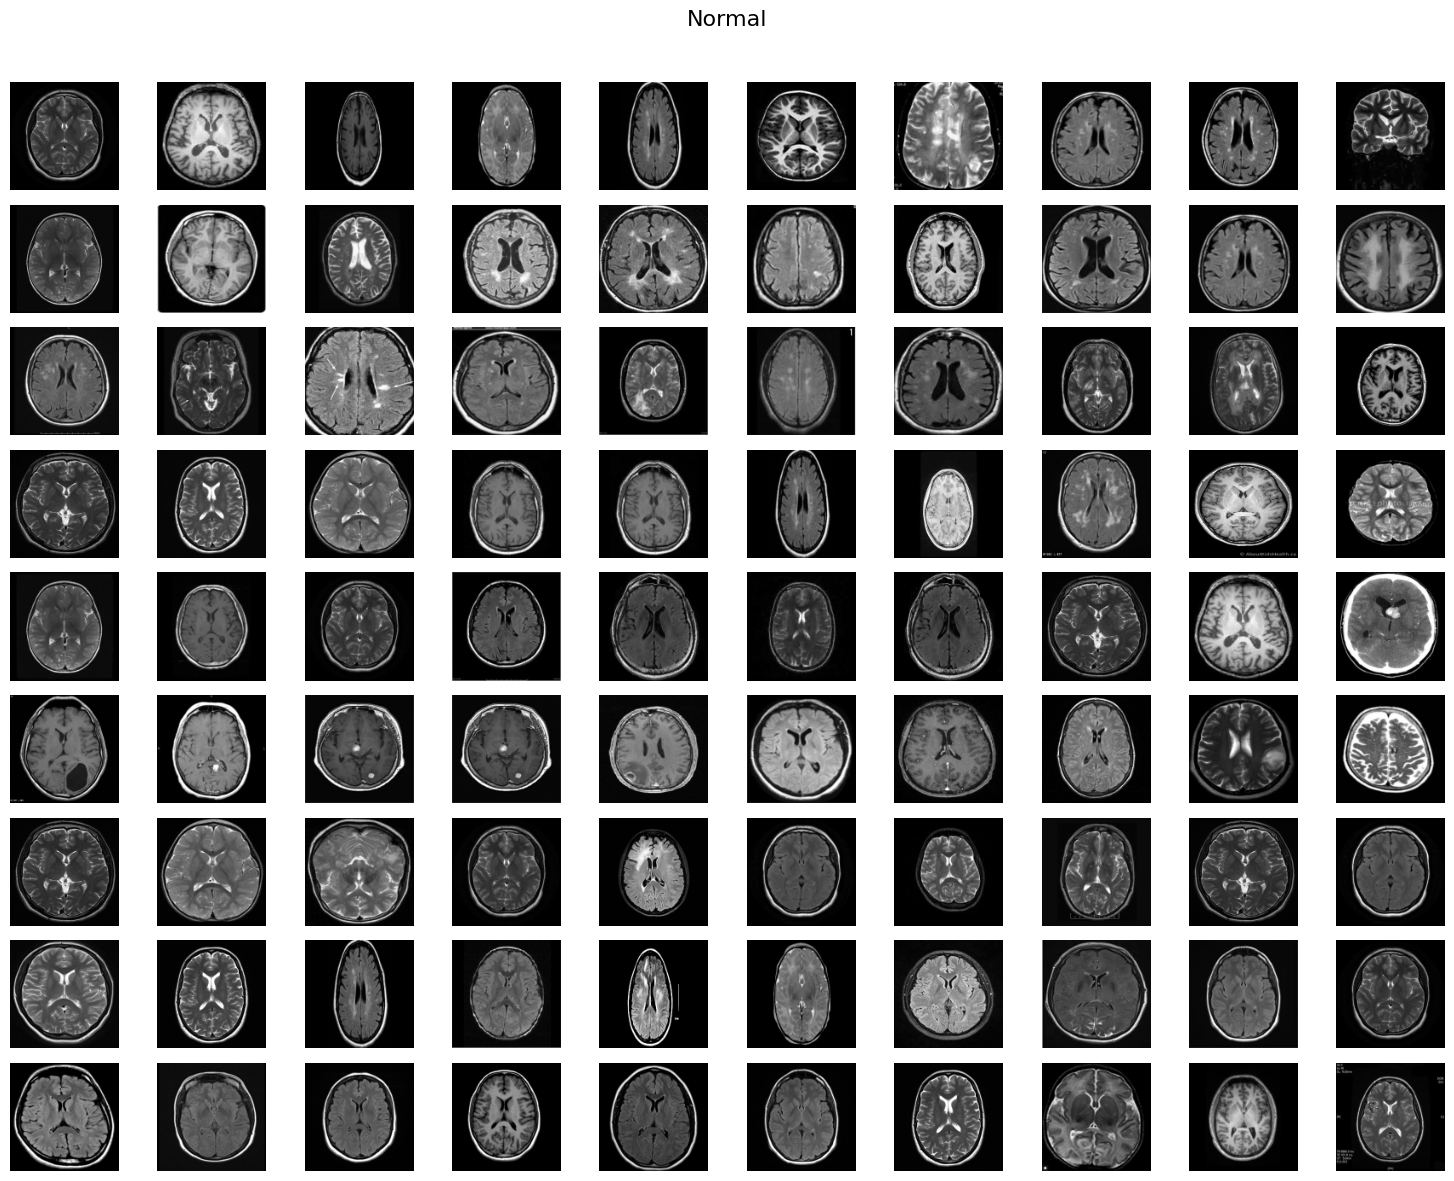

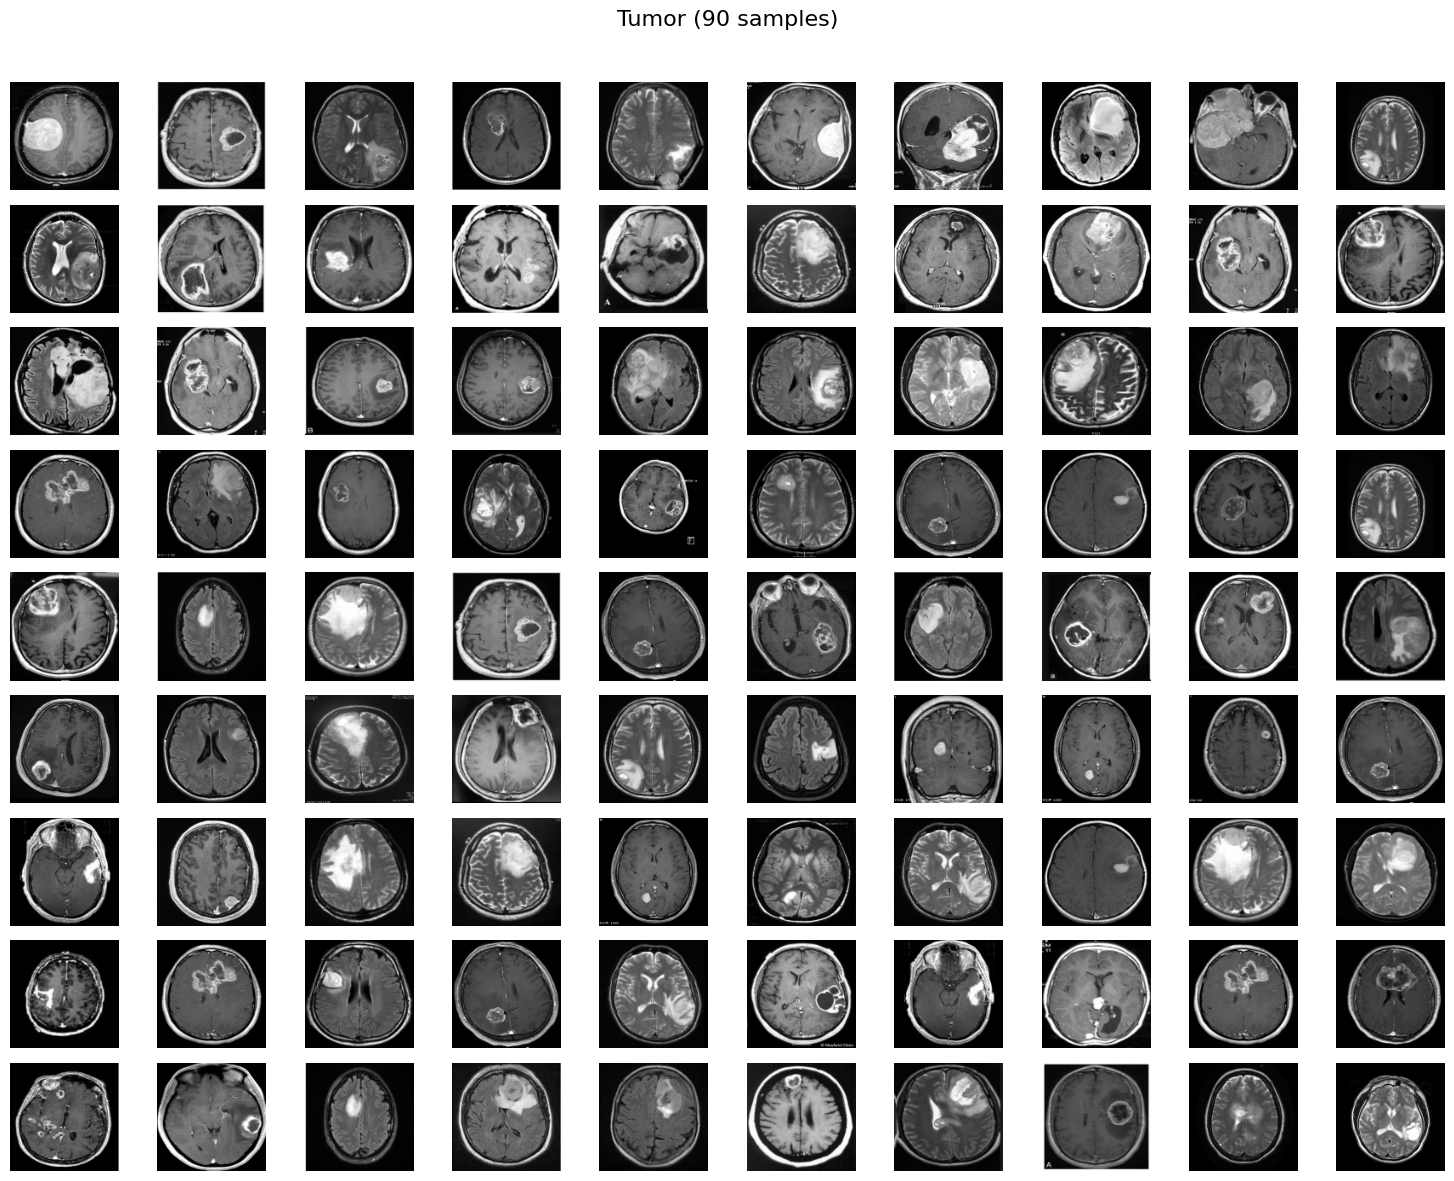

In [4]:
# ambil index berdasarkan label
normal_indx = [i for i, l in enumerate(labels) if l.lower() == "normal"]
tumor_indx = [i for i, l in enumerate(labels) if l.lower() == "tumor"]

# ambil maksimal 90
normal_indx = normal_indx[:90]
tumor_indx = tumor_indx[:90]


def show_images(idxs, title):
    fig, axs = plt.subplots(9, 10, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)

    for k in range(len(idxs)):
        row = k // 10
        col = k % 10
        axs[row][col].imshow(dataPreprocessed[idxs[k]], cmap='gray')
        axs[row][col].axis('off')

    # matikan subplot kosong
    for k in range(len(idxs), 90):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# tampilkan
show_images(normal_indx, "Normal")
show_images(tumor_indx, "Tumor (90 samples)")

## MENAMPILKAN JUMLAH DATA

Pada tahap ini dilakukan pengecekan jumlah keseluruhan citra, jumlah kelas yang tersedia, serta distribusi data pada masing-masing kelas. Informasi ini memberikan gambaran awal mengenai kondisi dataset dan membantu memastikan bahwa seluruh data berhasil dimuat dengan baik ke dalam sistem.

In [5]:
from collections import Counter

# -----------------------------
# 1. Menampilkan Jumlah Data
print("Jumlah total gambar:", len(data))
print("Jumlah kelas:", len(np.unique(labels)))
print("Distribusi per kelas:", Counter(labels))

Jumlah total gambar: 196
Jumlah kelas: 2
Distribusi per kelas: Counter({np.str_('normal'): 98, np.str_('tumor'): 98})


## DISTRIBUSI KELAS

Tahap distribusi kelas dilakukan untuk melihat penyebaran jumlah data pada setiap kategori yang terdapat dalam dataset. Melalui visualisasi ini, dapat diketahui apakah setiap kelas memiliki jumlah sampel yang relatif seimbang atau terdapat kelas tertentu yang memiliki jumlah data lebih banyak dibandingkan kelas lainnya. Informasi tersebut penting karena distribusi data yang tidak seimbang dapat memengaruhi kemampuan model dalam mempelajari karakteristik masing-masing kelas.

Visualisasi distribusi kelas juga membantu proses pemahaman dataset secara lebih cepat dan mudah. Dengan menampilkan jumlah data dalam bentuk grafik, perbedaan jumlah sampel antar kelas dapat terlihat secara langsung tanpa perlu melakukan pemeriksaan data secara manual. Tahap ini menjadi langkah awal untuk memastikan bahwa seluruh data telah terbaca dengan benar dan siap digunakan pada proses berikutnya.

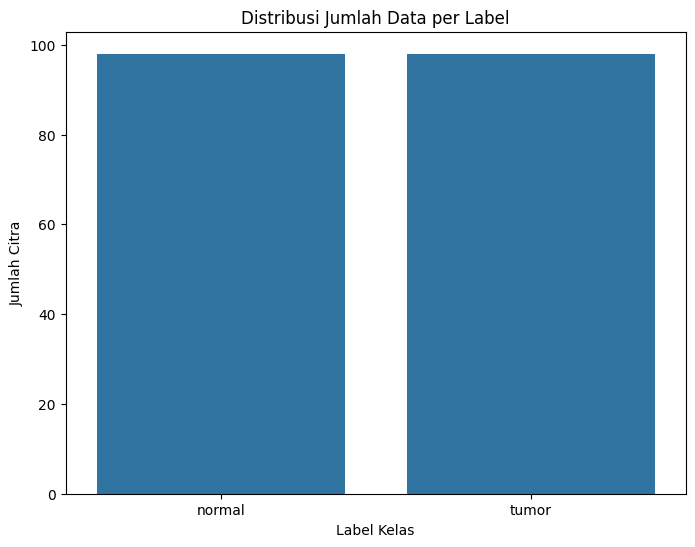

Total jumlah citra dalam dataset: 196
Total jumlah label dalam dataset: 196
Jumlah kelas unik: 2

Jumlah citra per kelas:
normal    98
tumor     98
Name: count, dtype: int64


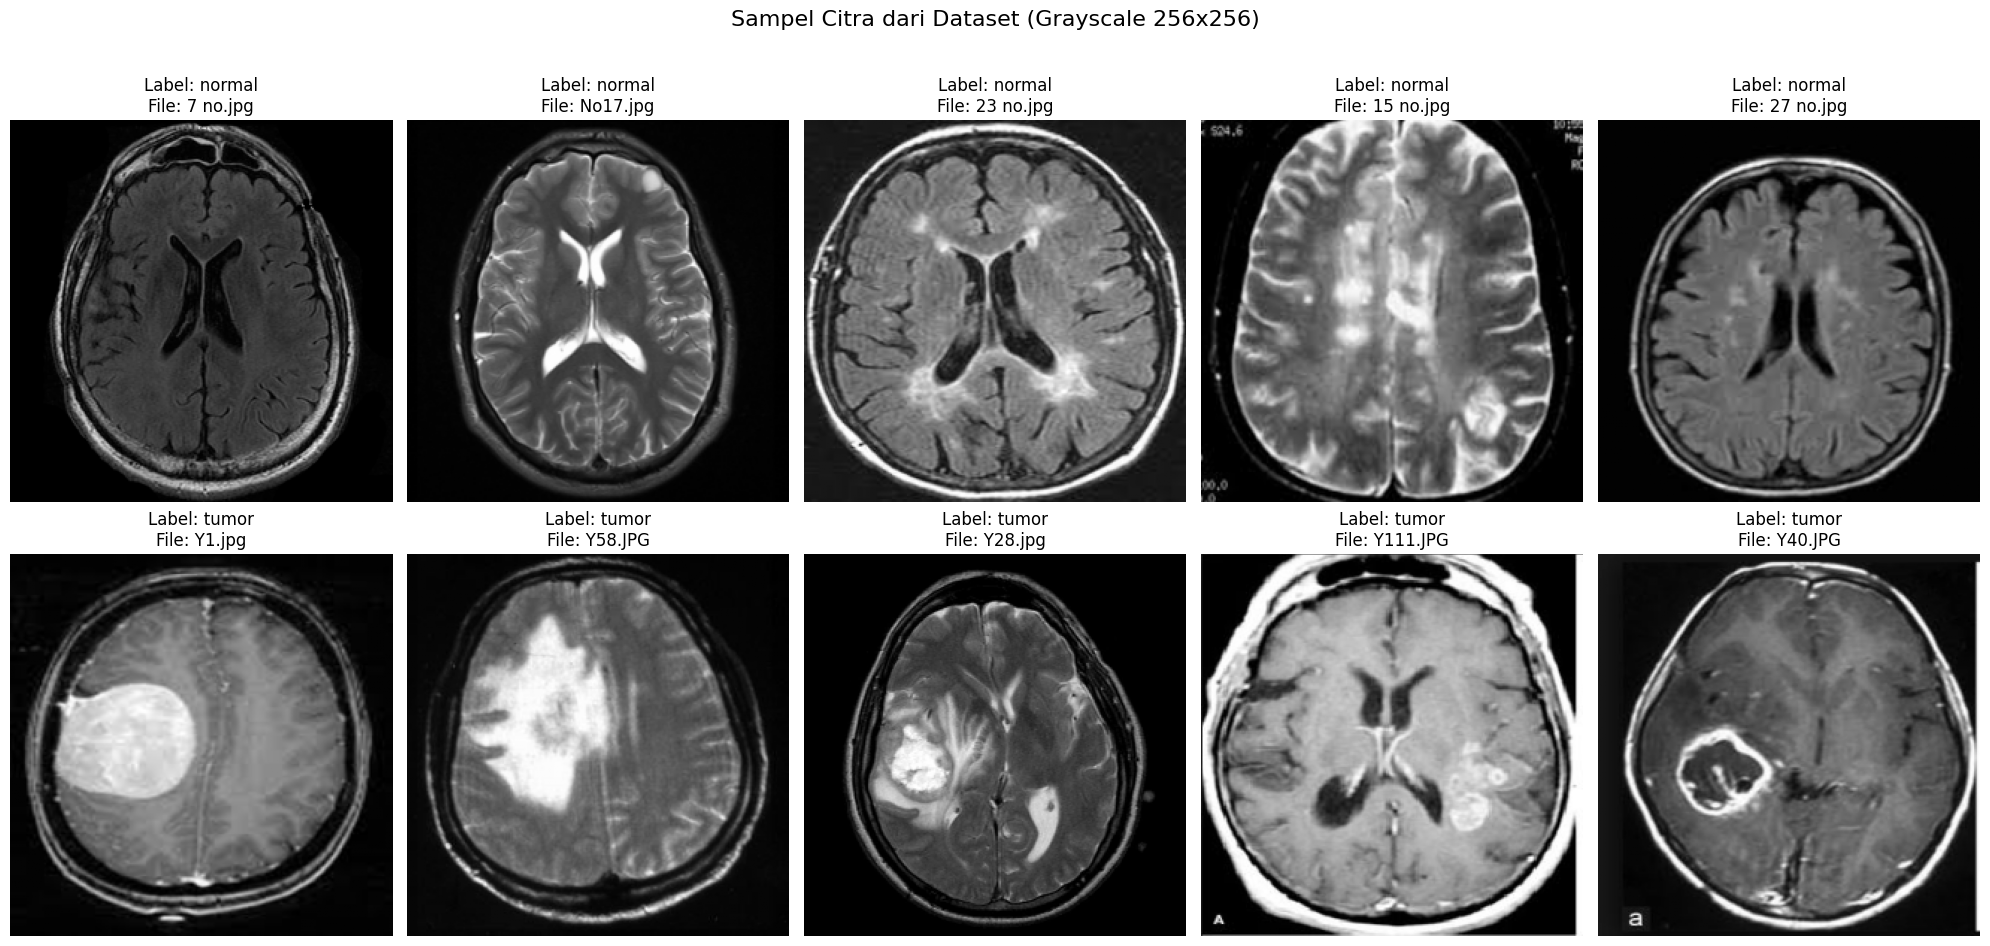

In [6]:
# Mengubah list labels menjadi pandas Series untuk memudahkan penghitungan
label_series = pd.Series(labels)

# Menghitung jumlah kemunculan setiap label
label_counts = label_series.value_counts()

# Membuat diagram batang
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribusi Jumlah Data per Label')
plt.xlabel('Label Kelas')
plt.ylabel('Jumlah Citra')
plt.show()

# Menampilkan jumlah data dan label secara keseluruhan
print(f"Total jumlah citra dalam dataset: {len(data)}")
print(f"Total jumlah label dalam dataset: {len(labels)}")
print(f"Jumlah kelas unik: {len(label_counts)}")
print("\nJumlah citra per kelas:")
print(label_counts)

# Mendapatkan indeks untuk kelas 'normal' dan 'tumor'
normal_indices = np.where(labels == 'normal')[0]
tumor_indices = np.where(labels == 'tumor')[0]

# Mengambil 5 sampel acak jika jumlahnya lebih dari 5, atau semua sampel jika kurang dari 5
num_samples_to_show = 5
if len(normal_indices) >= num_samples_to_show:
    sample_normal_indices = np.random.choice(normal_indices, num_samples_to_show, replace=False)
else:
    sample_normal_indices = normal_indices

if len(tumor_indices) >= num_samples_to_show:
    sample_tumor_indices = np.random.choice(tumor_indices, num_samples_to_show, replace=False)
else:
    sample_tumor_indices = tumor_indices
    
# Menggabungkan indeks sampel
sample_indices = np.concatenate((sample_normal_indices, sample_tumor_indices))

# Menampilkan citra sampel
plt.figure(figsize=(20, 10))
plt.suptitle('Sampel Citra dari Dataset (Grayscale 256x256)', fontsize=16)
for i, index in enumerate(sample_indices):
    plt.subplot(2, num_samples_to_show, i + 1)
    plt.imshow(data[index], cmap='gray') # Menampilkan citra grayscale
    plt.title(f"Label: {labels[index]}\nFile: {file_name[index]}")
    plt.axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Menyesuaikan layout agar supertitle tidak tumpang tindih
plt.show()

## Data Preparation

### Define Preprocessing Function
Pada tahap ini dibuat sebuah fungsi preprocessing yang berisi serangkaian langkah pengolahan citra yang akan diterapkan secara konsisten pada seluruh gambar dalam dataset. Penggunaan fungsi khusus membuat proses preprocessing menjadi lebih terstruktur karena setiap citra akan melalui tahapan yang sama tanpa perlu menuliskan kode berulang kali. Selain membuat kode lebih ringkas, pendekatan ini juga membantu menjaga konsistensi hasil pengolahan data.

## KERNEL SHARP DAN MORP
Pada tahap ini ditentukan dua kernel yang akan digunakan dalam proses preprocessing, yaitu kernel sharpening dan kernel morfologi. Kernel sharpening yang digunakan berukuran 3×3 dengan nilai pusat sebesar 9 dan nilai di sekelilingnya -1. Konfigurasi ini bertujuan untuk memperkuat perbedaan intensitas antar piksel sehingga tepi objek dan pola tekstur pada citra menjadi lebih jelas. Pemilihan kernel 3×3 cukup efektif karena mampu meningkatkan detail citra tanpa menghasilkan perubahan yang terlalu agresif yang berpotensi menambah noise.

Setelah proses penajaman, citra diproses menggunakan kernel morfologi berbentuk matriks 3×3 yang seluruh elemennya bernilai 1. Kernel ini digunakan sebagai structuring element dalam operasi morfologi untuk memperbaiki bentuk objek pada citra. Ukuran 3×3 dipilih karena mampu menghilangkan gangguan kecil pada citra sekaligus tetap mempertahankan detail penting dari objek yang diamati. Kernel yang terlalu besar berisiko menghilangkan informasi tekstur, sedangkan kernel yang terlalu kecil sering kali kurang efektif dalam membersihkan citra.

Kombinasi kedua kernel tersebut memberikan hasil yang saling melengkapi. Kernel sharpening membantu memperjelas pola tekstur yang akan dianalisis menggunakan GLCM, sedangkan kernel morfologi membantu memperbaiki struktur objek dan mengurangi gangguan yang tidak diperlukan. Dengan demikian, citra yang dihasilkan menjadi lebih bersih, detail teksturnya lebih terlihat, dan lebih siap untuk menghasilkan fitur yang representatif pada tahap ekstraksi fitur.

In [7]:
# --- 1. KERNEL ---
kernelSharpening = np.array([
    [ 0, -1,  0 ],
    [-1,  5, -1 ],
    [ 0, -1,  0 ]
])

kernelMorfologi = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)


  ## METODE DILASI
Proses dilasi merupakan salah satu operasi morfologi yang digunakan untuk memperluas area objek pada citra. Pada tahap ini, setiap piksel akan diproses menggunakan kernel morfologi berukuran 3×3 yang telah didefinisikan sebelumnya. Operasi ini menyebabkan area objek menjadi sedikit lebih besar sehingga bagian-bagian yang terputus atau celah kecil pada objek dapat tertutupi.

Penggunaan dilasi cukup bermanfaat setelah proses sharpening karena dapat memperkuat bentuk objek yang menjadi fokus analisis. Terkadang terdapat bagian tepi objek yang tipis atau kurang jelas akibat variasi pencahayaan maupun tekstur citra. Dengan dilasi, area tersebut dapat dipertegas sehingga bentuk objek menjadi lebih utuh dan mudah dikenali.

Kernel berukuran 3×3 dipilih karena mampu memberikan efek perluasan yang cukup tanpa mengubah bentuk objek secara berlebihan. Ukuran kernel yang lebih besar memang dapat mempercepat proses perluasan area objek, tetapi berisiko menghilangkan detail penting dan menyebabkan objek yang berdekatan saling menyatu. Oleh karena itu, kernel 3×3 sering digunakan karena memberikan keseimbangan antara perbaikan struktur objek dan pelestarian detail citra.

Hasil dari proses dilasi adalah citra dengan objek yang lebih tegas dan memiliki area yang lebih solid. Kondisi ini membantu menghasilkan representasi tekstur yang lebih stabil sehingga fitur yang diekstraksi pada tahap selanjutnya dapat menggambarkan karakteristik citra dengan lebih baik.

In [8]:

def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    pad_h, pad_w = k_height // 2, k_width // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    hasil = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            region = padded[i:i+k_height, j:j+k_width]
            hasil[i, j] = np.max(region[kernel == 1])
    return hasil

## METODE EROSI
Setelah proses dilasi, dilakukan operasi erosi untuk mengurangi atau mengikis bagian tepi objek pada citra. Erosi bekerja menggunakan kernel morfologi yang sama, yaitu berukuran 3×3, dengan cara menghapus piksel-piksel pada batas objek sesuai bentuk structuring element yang digunakan. Proses ini bertujuan untuk menghilangkan bagian-bagian kecil yang tidak diinginkan serta memperhalus bentuk objek.

Penggunaan erosi setelah dilasi merupakan kombinasi yang cukup umum dalam pengolahan citra. Dilasi sebelumnya memperluas area objek dan menutup celah-celah kecil, sedangkan erosi membantu mengembalikan ukuran objek agar tidak menjadi terlalu besar. Dengan cara ini, objek yang dihasilkan tetap memiliki bentuk yang lebih utuh namun tidak mengalami pelebaran berlebihan akibat proses dilasi.

Kernel 3×3 dipilih karena mampu memberikan efek pengikisan yang cukup ringan sehingga detail penting pada objek tetap terjaga. Jika kernel yang digunakan terlalu besar, sebagian informasi tekstur dan bentuk objek dapat hilang. Sebaliknya, kernel yang terlalu kecil sering kali kurang efektif dalam mengurangi gangguan atau memperbaiki bentuk objek.

Kombinasi dilasi dan erosi pada tahap preprocessing membantu menghasilkan citra yang lebih bersih dan stabil. Celah-celah kecil pada objek dapat diperbaiki oleh dilasi, sementara erosi membantu mempertahankan ukuran dan bentuk objek agar tetap proporsional. Hasil akhir dari proses ini adalah citra dengan struktur objek yang lebih jelas dan lebih siap untuk menghasilkan fitur tekstur yang akurat pada tahap ekstraksi fitur GLCM.

In [9]:
def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    pad_h, pad_w = k_height // 2, k_width // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    hasil = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            region = padded[i:i+k_height, j:j+k_width]
            hasil[i, j] = np.min(region[kernel == 1])
    return hasil

## METODE CLOSING ( DILASI -> EROSI)
Operasi closing merupakan salah satu teknik morfologi yang dilakukan dengan menggabungkan proses dilasi terlebih dahulu, kemudian dilanjutkan dengan erosi menggunakan kernel yang sama, yaitu 3×3. Tujuan utama dari metode ini adalah untuk menutup celah-celah kecil, lubang kecil di dalam objek, serta memperbaiki bagian tepi objek yang belum tersambung dengan sempurna.

Penggunaan closing sangat bermanfaat ketika objek pada citra masih memiliki area yang terputus atau terdapat bagian kosong kecil yang seharusnya menjadi satu kesatuan. Proses dilasi pada tahap awal membantu memperluas area objek dan menutup celah tersebut, sedangkan erosi yang dilakukan setelahnya mengembalikan ukuran objek agar tidak menjadi terlalu besar. Hasilnya, objek menjadi lebih utuh tanpa mengalami perubahan bentuk yang signifikan.

In [10]:
def closing(image, kernel):
    return erosi(dilasi(image, kernel), kernel)
  

## METODE OPENING -> (EROSI -> DILASI)
Operasi opening merupakan operasi morfologi yang dilakukan dengan urutan erosi terlebih dahulu kemudian dilanjutkan dengan dilasi menggunakan kernel berukuran 3×3. Berbeda dengan closing yang berfokus pada penutupan celah kecil, opening lebih ditujukan untuk menghilangkan objek-objek kecil atau noise yang tidak diinginkan pada citra tanpa merusak bentuk utama objek yang menjadi fokus analisis.

Pada tahap erosi, piksel-piksel kecil yang berada di sekitar tepi objek atau noise berukuran kecil akan dikurangi sehingga gangguan pada citra dapat diminimalkan. Setelah itu, proses dilasi dilakukan untuk mengembalikan ukuran objek utama yang sebelumnya sedikit menyusut akibat erosi. Kombinasi kedua proses ini menghasilkan citra yang lebih bersih tanpa kehilangan struktur penting dari objek utama.

In [11]:

def opening(image, kernel):
    return dilasi(erosi(image, kernel), kernel)



## METODE PERCOBAAN 3
Pada percobaan ini, preprocessing dilakukan dengan mengombinasikan metode opening dan closing setelah citra melalui tahap baseline. Tahap baseline berfungsi untuk menyeragamkan ukuran citra menjadi 128×128 piksel serta mengubah citra menjadi grayscale sehingga proses pengolahan berikutnya dapat dilakukan secara lebih konsisten.

Setelah itu, citra diproses menggunakan metode opening dengan kernel morfologi berukuran 3×3. Metode ini terdiri dari proses erosi yang diikuti dilasi dan bertujuan untuk mengurangi noise atau objek-objek kecil yang tidak diinginkan pada citra. Dengan berkurangnya gangguan tersebut, tekstur utama pada citra menjadi lebih jelas dan tidak terlalu dipengaruhi oleh piksel-piksel yang tidak relevan.

Tahap berikutnya adalah closing, yaitu kombinasi dilasi yang diikuti erosi menggunakan kernel yang sama. Setelah noise kecil berhasil dikurangi oleh proses opening, metode closing digunakan untuk menutup celah-celah kecil atau area yang belum tersambung sempurna pada objek. Proses ini membantu menghasilkan struktur objek yang lebih utuh dan lebih konsisten.

Urutan opening kemudian closing dipilih karena kedua metode tersebut memiliki fungsi yang saling melengkapi. Opening berperan membersihkan citra dari gangguan berukuran kecil, sedangkan closing membantu memperbaiki bentuk objek yang mungkin masih memiliki celah atau ketidakteraturan setelah proses pembersihan. Kombinasi ini menghasilkan citra yang lebih bersih dan memiliki struktur objek yang lebih stabil sehingga karakteristik tekstur yang diekstraksi pada tahap GLCM dapat merepresentasikan kondisi citra dengan lebih baik.

In [12]:
def percobaan3(img):
    img_base = baseline(img)
    img_opened = opening(img_base, kernelMorfologi)
    img_closed = closing(img_opened, kernelMorfologi)
    
    return img_closed

### Preprocessing
Pada tahap ini, seluruh citra yang telah berhasil dimuat ke dalam dataset diproses menggunakan fungsi percobaan3() yang telah didefinisikan sebelumnya. Setiap gambar akan melalui rangkaian preprocessing yang terdiri dari proses baseline (grayscale dan resize 128×128 piksel), dilanjutkan dengan operasi opening dan closing menggunakan kernel morfologi 3×3. Tujuan utama dari proses ini adalah menghasilkan citra yang lebih seragam dan memiliki kualitas yang lebih baik sebelum memasuki tahap ekstraksi fitur.

Proses preprocessing dilakukan secara berulang menggunakan perulangan (loop) sehingga seluruh data dapat diproses secara otomatis tanpa perlu mengolah setiap citra secara manual. Hasil dari setiap proses preprocessing kemudian disimpan ke dalam variabel dataPreprocessed. Pendekatan ini membuat seluruh dataset memiliki perlakuan yang sama, sehingga karakteristik citra menjadi lebih konsisten dan dapat mengurangi variasi yang disebabkan oleh perbedaan ukuran maupun gangguan pada citra asli.

Setelah seluruh citra selesai diproses, data hasil preprocessing dikonversi menjadi NumPy Array. Bentuk penyimpanan ini dipilih karena lebih efisien untuk pengolahan data numerik dan kompatibel dengan berbagai proses analisis selanjutnya, termasuk ekstraksi fitur GLCM dan pelatihan model klasifikasi. Selain itu, ukuran data yang ditampilkan melalui dataPreprocessed.shape digunakan untuk memastikan bahwa seluruh citra berhasil diproses dan tersimpan dengan benar.

Sebagai tahap verifikasi, satu sampel citra hasil preprocessing ditampilkan menggunakan visualisasi. Tampilan ini berguna untuk memastikan bahwa seluruh tahapan preprocessing telah berjalan sesuai harapan. Melalui visualisasi tersebut, dapat diamati apakah citra telah berhasil diubah menjadi grayscale, memiliki ukuran yang seragam, serta menunjukkan hasil perbaikan struktur objek setelah penerapan metode opening dan closing. Dengan demikian, kualitas data dapat diperiksa sebelum melanjutkan ke tahap ekstraksi fitur.

Memulai proses preprocessing...
Preprocessing Selesai! Ukuran data: (196, 128, 128)


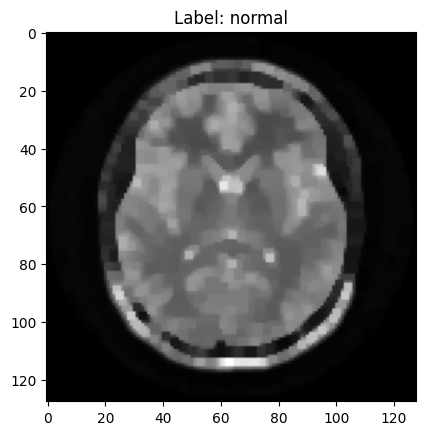

In [13]:
dataPreprocessed = []
print("Memulai proses preprocessing...")

for i in range(len(data)): 
    img_hasil = percobaan3(data[i]) 
    
    dataPreprocessed.append(img_hasil)

dataPreprocessed = np.array(dataPreprocessed)
print("Preprocessing Selesai! Ukuran data:", dataPreprocessed.shape)

# Tampilkan sampel
plt.imshow(dataPreprocessed[0], cmap='gray')
plt.title(f"Label: {labels[0]}")
plt.show()

### Feature Extraction
Pada tahap ini dibuat fungsi untuk membentuk Gray Level Co-occurrence Matrix (GLCM) dari citra hasil preprocessing. GLCM digunakan untuk merepresentasikan tekstur citra dengan menghitung hubungan kemunculan pasangan piksel berdasarkan nilai intensitasnya. Matriks yang dihasilkan akan menjadi dasar dalam proses ekstraksi fitur tekstur pada tahap berikutnya.

Fungsi ini mendukung empat arah pengamatan, yaitu 0°, 45°, 90°, dan 135°. Penggunaan beberapa sudut bertujuan untuk menangkap pola tekstur dari berbagai orientasi karena karakteristik tekstur tidak selalu muncul pada satu arah tertentu. Dengan demikian, informasi tekstur yang diperoleh menjadi lebih lengkap dan mampu menggambarkan kondisi citra secara lebih baik.

Pada pembentukan GLCM digunakan jarak 1 piksel dengan 256 tingkat keabuan (0–255). Parameter symmetric=True digunakan agar hubungan antar piksel dihitung secara dua arah, sedangkan normed=True digunakan untuk melakukan normalisasi nilai matriks sehingga hasil yang diperoleh lebih konsisten. Matriks GLCM yang terbentuk kemudian digunakan untuk menghitung berbagai fitur tekstur yang akan menjadi masukan pada proses klasifikasi.

In [14]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Kode ini mendefinisikan fungsi `correlation` yang digunakan untuk mengekstrak fitur korelasi dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi memanfaatkan `graycoprops` dari library `skimage.feature` dengan parameter `'correlation'` untuk menghitung tingkat korelasi antar piksel dalam citra berdasarkan GLCM yang diberikan. Nilai korelasi ini menggambarkan hubungan linier antara intensitas piksel yang berdekatan dan dapat menjadi fitur penting dalam membedakan tekstur antar kelas.

In [15]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

Kode ini mendefinisikan fungsi `dissimilarity` untuk mengambil fitur dissimilarity dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `graycoprops` dari `skimage.feature` dengan parameter `'dissimilarity'` untuk mengukur seberapa berbeda intensitas piksel yang berdekatan dalam citra. Nilai dissimilarity ini membantu dalam menangkap variasi tekstur dan perbedaan lokal pada citra, yang berguna untuk proses klasifikasi citra.

In [16]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

Kode ini mendefinisikan fungsi `homogenity` yang digunakan untuk mengekstrak fitur homogeneity dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi memanfaatkan `graycoprops` dari library `skimage.feature` dengan parameter `'homogeneity'` untuk mengukur seberapa seragam tekstur dalam citra, yaitu seberapa dekat distribusi elemen dalam GLCM ke diagonal utamanya. Nilai homogeneity yang tinggi menunjukkan tekstur yang lebih seragam, yang dapat membantu membedakan karakteristik tekstur antar kelas citra tumor.

In [17]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

Kode ini mendefinisikan fungsi `contrast` untuk mengekstrak fitur contrast dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `graycoprops` dari `skimage.feature` dengan parameter `'contrast'` untuk mengukur perbedaan intensitas lokal dalam citra. Nilai contrast yang tinggi menunjukkan adanya variasi tekstur yang kuat, sehingga fitur ini berguna untuk membedakan pola dan tekstur pada citra dalam proses klasifikasi.

In [18]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

Kode ini mendefinisikan fungsi `ASM` untuk mengekstrak fitur Angular Second Moment (ASM) dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `graycoprops` dari `skimage.feature` dengan parameter `'ASM'`, yang mengukur tingkat keseragaman atau energi tekstur dalam citra. Nilai ASM yang tinggi menunjukkan tekstur yang lebih homogen dan teratur, sehingga fitur ini membantu dalam analisis dan klasifikasi pola tekstur citra tumor.

In [19]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

Kode ini mendefinisikan fungsi `energy` yang digunakan untuk mengekstrak fitur energy dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi memanfaatkan `graycoprops` dari library `skimage.feature` dengan parameter `'energy'`, yang merupakan akar kuadrat dari Angular Second Moment (ASM) dan mencerminkan keseragaman tekstur dalam citra. Nilai energy yang tinggi menunjukkan tekstur yang lebih konsisten dan beraturan, sehingga fitur ini penting untuk proses klasifikasi.

In [20]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

Kode ini mendefinisikan fungsi `entropyGlcm` untuk menghitung fitur entropy dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `entropy` dari modul `scipy.stats` pada matriks GLCM yang telah diratakan (dirubah menjadi vektor satu dimensi) untuk mengukur tingkat ketidakteraturan atau kompleksitas tekstur citra. Nilai entropy yang tinggi menunjukkan tekstur yang lebih acak dan tidak teratur, sehingga fitur ini membantu dalam membedakan karakteristik tekstur antar kelas citra.

In [21]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Ekstraksi GLCM pada Berbagai Derajat
Kode ini melakukan ekstraksi Gray-Level Co-occurrence Matrix (GLCM) dari setiap citra dalam `dataPreprocessed` pada empat arah sudut yang berbeda: 0°, 45°, 90°, dan 135°. Dengan menggunakan fungsi `glcm`, setiap citra diproses untuk menghasilkan matriks GLCM pada masing-masing derajat tersebut, yang kemudian disimpan dalam list terpisah (`Derajat0`, `Derajat45`, `Derajat90`, `Derajat135`). Ekstraksi pada berbagai arah ini berguna untuk menangkap tekstur citra secara lebih menyeluruh, karena pola tekstur dapat bervariasi tergantung arah pengamatannya.

In [22]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

## Inisialisasi Variabel untuk Fitur GLCM
Kode ini membuat beberapa list kosong untuk menyimpan nilai fitur tekstur yang diekstrak dari matriks GLCM pada masing-masing sudut 0°, 45°, 90°, dan 135°. Fitur-fitur tersebut meliputi kontras (contrast), dissimilarity, homogenitas (homogeneity), entropi (entropy), angular second moment (ASM), energi (energy), dan korelasi (correlation). Setiap fitur memiliki empat list terpisah sesuai dengan arah ekstraksi GLCM, yang nantinya akan diisi dengan nilai-nilai hasil ekstraksi pada cell-cell berikutnya.

In [23]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


## Ekstraksi Fitur Korelasi dari GLCM pada Berbagai Derajat
Kode ini menghitung nilai fitur korelasi (correlation) dari matriks GLCM yang sudah diekstraksi pada empat sudut berbeda (0°, 45°, 90°, dan 135°) untuk setiap citra dalam `dataPreprocessed`. Fungsi `correlation()` digunakan untuk mengambil nilai korelasi dari masing-masing matriks GLCM, kemudian hasilnya disimpan ke dalam list yang sesuai (`correlation0`, `correlation45`, `correlation90`, `correlation135`).

In [24]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

## Ekstraksi Fitur Kontras dari GLCM pada Berbagai Derajat
Kode ini melakukan perhitungan nilai fitur kontras (contrast) dari matriks GLCM yang telah diekstraksi pada sudut 0°, 45°, 90°, dan 135° untuk setiap citra. Fungsi `contrast()` digunakan untuk memperoleh nilai kontras dari masing-masing matriks GLCM, kemudian nilai-nilai tersebut disimpan dalam list terpisah (`Kontras0`, `Kontras45`, `Kontras90`, dan `Kontras135`). Perlu diperhatikan bahwa perulangan pada cell ini menggunakan `len(data)` sebagai acuan jumlah iterasi, bukan `len(dataPreprocessed)` seperti pada cell ekstraksi GLCM sebelumnya, sehingga jumlah iterasi akan tetap konsisten selama panjang `data` dan `dataPreprocessed` sama.

In [25]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

## Ekstraksi Fitur Dissimilarity dari GLCM pada Berbagai Derajat
Kode ini mengekstrak nilai fitur dissimilarity dari matriks GLCM yang dihasilkan pada sudut 0°, 45°, 90°, dan 135° untuk setiap citra. Fungsi `dissimilarity()` digunakan untuk menghitung tingkat perbedaan intensitas antar piksel pada citra, kemudian hasilnya disimpan dalam list terpisah (`dissimilarity0`, `dissimilarity45`, `dissimilarity90`, dan `dissimilarity135`).

In [26]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

## Ekstraksi Fitur Homogeneity dari GLCM pada Berbagai Derajat
Kode ini melakukan ekstraksi fitur homogeneity dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. Fungsi `homogenity()` digunakan untuk mengukur keseragaman atau tingkat kemiripan intensitas piksel yang berdekatan, dan hasilnya disimpan dalam list `homogenity0`, `homogenity45`, `homogenity90`, dan `homogenity135`.

In [27]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

## Ekstraksi Fitur Entropy dari GLCM pada Berbagai Derajat
Kode ini mengekstrak fitur entropy dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. Fungsi `entropyGlcm()` menghitung entropi, yaitu ukuran ketidakteraturan atau kompleksitas tekstur citra, dari nilai-nilai matriks GLCM yang diratakan. Nilai entropy ini kemudian disimpan dalam list `entropy0`, `entropy45`, `entropy90`, dan `entropy135`.

In [28]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

## Ekstraksi Fitur ASM (Angular Second Moment) dari GLCM pada Berbagai Derajat
Kode ini menghitung fitur Angular Second Moment (ASM) dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. ASM adalah ukuran homogenitas tekstur yang tinggi, menunjukkan seberapa seragam pola tekstur pada citra. Nilai ASM dari setiap derajat disimpan ke dalam list `ASM0`, `ASM45`, `ASM90`, dan `ASM135`.

In [29]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

## Ekstraksi Fitur Energy dari GLCM pada Berbagai Derajat
Kode ini menghitung fitur Energy dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. Energy merupakan akar kuadrat dari ASM dan mengukur kekompakan atau keteraturan tekstur dalam citra. Nilai energy untuk tiap derajat disimpan dalam list `energy0`, `energy45`, `energy90`, dan `energy135`.

In [30]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

In [31]:
print("Panjang file_name:", len(file_name))
print("Panjang labels:", len(labels))
print("Panjang Kontras0:", len(Kontras0))
print("Panjang correlation0:", len(correlation0))

Panjang file_name: 196
Panjang labels: 196
Panjang Kontras0: 196
Panjang correlation0: 196


### Write the extraction's results to CSV
Kode ini menggabungkan seluruh fitur tekstur hasil ekstraksi GLCM dari berbagai derajat (0°, 45°, 90°, 135°) beserta label dan nama file gambar ke dalam sebuah dictionary bernama `dataTable`. Dictionary ini kemudian diubah menjadi DataFrame menggunakan pandas dan disimpan ke file CSV bernama `'hasil_ekstraksi_1.csv'` tanpa menyertakan indeks. Selanjutnya, file CSV tersebut dibaca kembali ke dalam variabel `hasilEkstrak` untuk memastikan data tersimpan dengan benar dan siap digunakan pada tahap seleksi fitur.

In [32]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1 no.jpeg,normal,46.403297,90.589373,55.716535,85.636431,0.734516,0.617879,0.748093,0.624530,...,0.064276,0.056101,0.251777,0.236108,0.253528,0.236856,0.969361,0.940245,0.963212,0.943512
1,10 no.jpg,normal,53.339321,89.318495,44.612697,88.473185,0.639188,0.481737,0.639942,0.481673,...,0.054579,0.048552,0.233783,0.220182,0.233621,0.220344,0.981779,0.969377,0.984760,0.969666
2,11 no.jpg,normal,49.592889,90.115568,51.687131,86.499721,0.841783,0.782961,0.861201,0.780413,...,0.451763,0.440747,0.668555,0.663711,0.672133,0.663887,0.967477,0.941228,0.966104,0.943586
3,12 no.jpg,normal,81.994710,110.374977,40.570497,105.320975,0.805068,0.720840,0.820984,0.721383,...,0.302694,0.291753,0.546839,0.540385,0.550176,0.540141,0.982259,0.976196,0.991222,0.977286
4,13 no.jpg,normal,126.527190,181.038998,64.528051,166.486329,0.802274,0.716034,0.815430,0.713612,...,0.184268,0.170326,0.422993,0.412837,0.429264,0.412706,0.954563,0.935246,0.976827,0.940451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Y95.jpg,tumor,58.177411,83.607787,32.602116,77.807552,0.740298,0.612180,0.741937,0.611014,...,0.077438,0.066192,0.282449,0.258367,0.278277,0.257278,0.982307,0.974610,0.990085,0.976372
192,Y96.jpg,tumor,122.322958,181.620435,89.846088,182.117180,0.726428,0.609942,0.741925,0.609564,...,0.099679,0.093145,0.316049,0.304892,0.315719,0.305197,0.944439,0.917410,0.959190,0.917184
193,Y97.JPG,tumor,98.603469,171.082274,93.079478,185.702027,0.575331,0.406170,0.599617,0.405008,...,0.007250,0.004595,0.084077,0.067896,0.085147,0.067783,0.983796,0.971718,0.984704,0.969301
194,Y98.JPG,tumor,141.860974,226.407093,116.446112,229.803584,0.676118,0.554641,0.713523,0.554854,...,0.069442,0.059931,0.257813,0.244382,0.263518,0.244809,0.957166,0.931348,0.964840,0.930318


### Features Selection

pada bagian seleksi fitur ini bisa menggunakan metode seperti
- PCA
- LDA
- t-SNE
- Chi-square
- ANOVA
- Autoencoder
- correlation
- dll

berikut contoh menggunakan correlation:

Kode ini melakukan seleksi fitur menggunakan pendekatan korelasi antar fitur. Pertama, dihitung matriks korelasi antar seluruh kolom fitur pada `hasilEkstrak` (setelah kolom `Label` dan `Filename` dihapus). Selanjutnya, ditentukan sebuah `threshold` (di sini diatur sebesar 0.95) sebagai batas korelasi absolut antar dua fitur; apabila korelasi antara dua fitur melebihi batas tersebut, salah satu dari kedua fitur tersebut akan ditandai untuk dihapus (`columns[j] = False`) karena dianggap membawa informasi yang redundan. Fitur-fitur yang tersisa setelah penyaringan ini disimpan dalam `select`, dan digunakan untuk membentuk dataset fitur baru `x_new`, sementara label kelas disimpan dalam `y`. Sebagai langkah verifikasi, hasil korelasi antar fitur yang tersisa divisualisasikan menggunakan heatmap dari `seaborn` agar lebih mudah diamati apakah masih terdapat fitur dengan korelasi tinggi setelah proses penyaringan.

<Axes: >

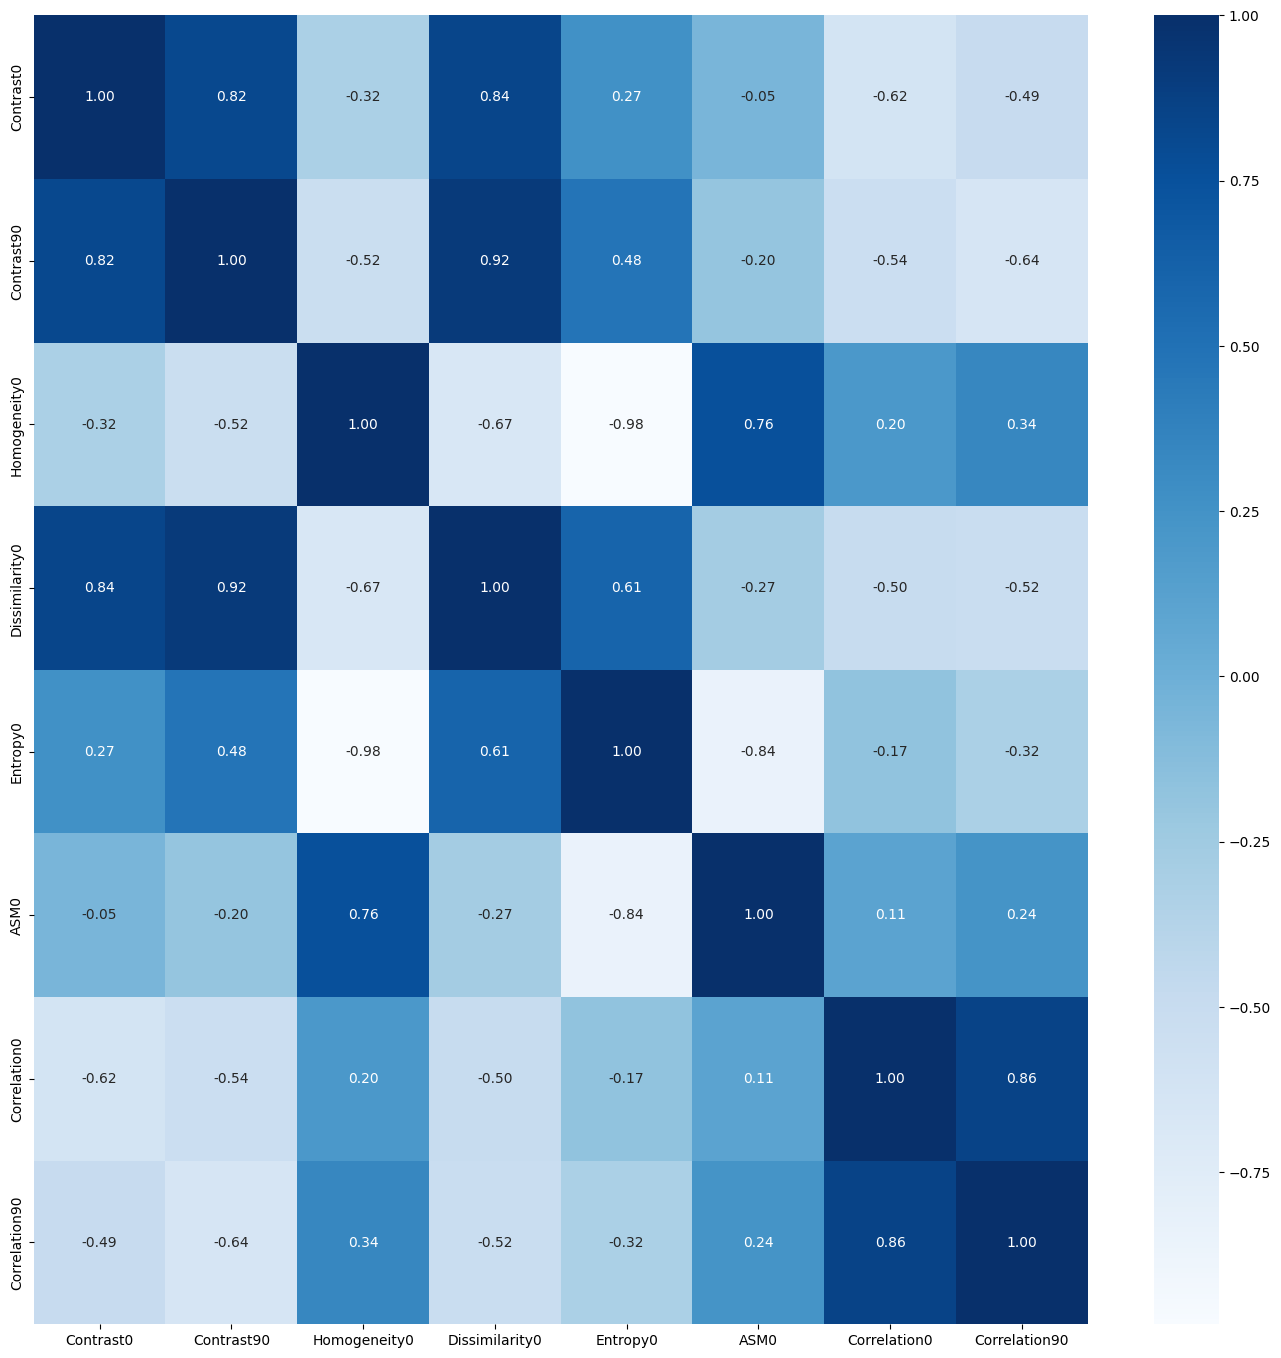

In [33]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Splitting Data

Kode ini melakukan pembagian dataset fitur (`x_new`) dan label (`y`) menjadi data pelatihan (train) dan pengujian (test) menggunakan fungsi `train_test_split` dari scikit-learn. Parameter `test_size=0.2` menunjukkan bahwa 20% data dialokasikan untuk testing, sedangkan 80% sisanya untuk training. Pengaturan `random_state=42` digunakan agar pembagian data ini konsisten dan dapat direproduksi. Setelah pembagian, kode mencetak bentuk (shape) dari dataset train dan test untuk memastikan proporsi pembagian data sudah sesuai yang diharapkan.

In [34]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(156, 8)
(40, 8)


## Feature Normalization

berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):

Kode ini melakukan normalisasi fitur pada data train dan test menggunakan metode standardisasi (z-score normalization). Data train dinormalisasi dengan mengurangi nilai rata-rata (`mean`) dan membagi dengan standar deviasi (`std`) dari data train itu sendiri, agar fitur memiliki distribusi dengan rata-rata 0 dan standar deviasi 1. Data test juga dinormalisasi menggunakan mean dan std yang sama dari data train (bukan dari data test) agar skala kedua dataset konsisten dan tidak terjadi kebocoran informasi (data leakage) dari data test ke proses normalisasi.

In [35]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

### Define Model

Kode ini mendefinisikan fungsi `generateClassificationReport` untuk mencetak laporan evaluasi model klasifikasi yang mencakup classification report (precision, recall, f1-score), confusion matrix, dan akurasi. Selain itu, tiga algoritma klasifikasi didefinisikan: Random Forest dengan 5 pohon keputusan (`n_estimators=5`), Support Vector Machine (SVM) dengan kernel RBF, dan K-Nearest Neighbors (KNN) dengan 5 tetangga (`n_neighbors=5`). Ketiga model ini akan digunakan dan dibandingkan performanya pada tahap pelatihan dan evaluasi selanjutnya.

In [36]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

Kode ini melatih model Random Forest menggunakan data latih (`X_train`, `y_train`). Setelah pelatihan selesai, model digunakan untuk melakukan prediksi pada data latih dan data uji (`X_test`). Hasil prediksi tersebut kemudian dievaluasi dengan fungsi `generateClassificationReport` yang menampilkan classification report, confusion matrix, dan akurasi untuk kedua set data. Tujuan dari langkah ini adalah untuk mengetahui seberapa baik model dapat mengklasifikasikan data latih maupun data yang belum pernah dilihat sebelumnya, serta untuk mendeteksi indikasi overfitting apabila akurasi pada data latih jauh lebih tinggi dibandingkan data uji.

In [37]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      normal       0.97      0.97      0.97        77
       tumor       0.97      0.97      0.97        79

    accuracy                           0.97       156
   macro avg       0.97      0.97      0.97       156
weighted avg       0.97      0.97      0.97       156

[[75  2]
 [ 2 77]]
Accuracy: 0.9743589743589743

------Testing Set------
              precision    recall  f1-score   support

      normal       0.78      0.67      0.72        21
       tumor       0.68      0.79      0.73        19

    accuracy                           0.72        40
   macro avg       0.73      0.73      0.72        40
weighted avg       0.73      0.72      0.72        40

[[14  7]
 [ 4 15]]
Accuracy: 0.725


### Train SVM Classifier

Kode ini melatih model Support Vector Machine (SVM) dengan kernel RBF menggunakan data latih (`X_train`, `y_train`). Setelah model dilatih, prediksi dilakukan pada data latih dan data uji (`X_test`). Fungsi `generateClassificationReport` digunakan untuk menampilkan metrik evaluasi seperti classification report, confusion matrix, dan akurasi pada kedua set data. Langkah ini bertujuan mengukur performa model SVM dalam mengklasifikasikan citra tumor berdasarkan fitur tekstur GLCM yang telah diekstraksi dan diseleksi sebelumnya.

In [38]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      normal       0.77      0.71      0.74        77
       tumor       0.74      0.80      0.77        79

    accuracy                           0.76       156
   macro avg       0.76      0.76      0.76       156
weighted avg       0.76      0.76      0.76       156

[[55 22]
 [16 63]]
Accuracy: 0.7564102564102564

------Testing Set------
              precision    recall  f1-score   support

      normal       0.71      0.71      0.71        21
       tumor       0.68      0.68      0.68        19

    accuracy                           0.70        40
   macro avg       0.70      0.70      0.70        40
weighted avg       0.70      0.70      0.70        40

[[15  6]
 [ 6 13]]
Accuracy: 0.7


### Train KNN Classifier

Kode ini melatih model K-Nearest Neighbors (KNN) dengan `k=5` menggunakan data latih (`X_train`, `y_train`). Setelah pelatihan selesai, model melakukan prediksi pada data latih dan data uji (`X_test`). Fungsi `generateClassificationReport` kemudian digunakan untuk menampilkan hasil evaluasi berupa classification report, confusion matrix, dan akurasi untuk kedua set data tersebut. Proses ini bertujuan untuk menilai kemampuan model KNN dalam mengklasifikasikan fitur tekstur citra tumor berdasarkan jarak terhadap tetangga terdekatnya.

In [39]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
              precision    recall  f1-score   support

      normal       0.75      0.71      0.73        77
       tumor       0.73      0.77      0.75        79

    accuracy                           0.74       156
   macro avg       0.74      0.74      0.74       156
weighted avg       0.74      0.74      0.74       156

[[55 22]
 [18 61]]
Accuracy: 0.7435897435897436

------Testing Set------
              precision    recall  f1-score   support

      normal       0.69      0.43      0.53        21
       tumor       0.56      0.79      0.65        19

    accuracy                           0.60        40
   macro avg       0.62      0.61      0.59        40
weighted avg       0.63      0.60      0.59        40

[[ 9 12]
 [ 4 15]]
Accuracy: 0.6


## Evaluation With Confusion Matrix

Kode ini mendefinisikan fungsi `plot_confusion_matrix` untuk memvisualisasikan matriks kebingungan (confusion matrix) dari hasil prediksi model klasifikasi. Fungsi menerima label asli (`y_true`), prediksi model (`y_pred`), dan judul grafik sebagai input, kemudian menampilkan heatmap confusion matrix dengan palet warna biru. Fungsi ini kemudian dipanggil untuk ketiga model yang telah dilatih: Random Forest, SVM, dan KNN, guna menampilkan perbandingan visual performa masing-masing model dalam mengklasifikasikan citra tumor pada data uji.

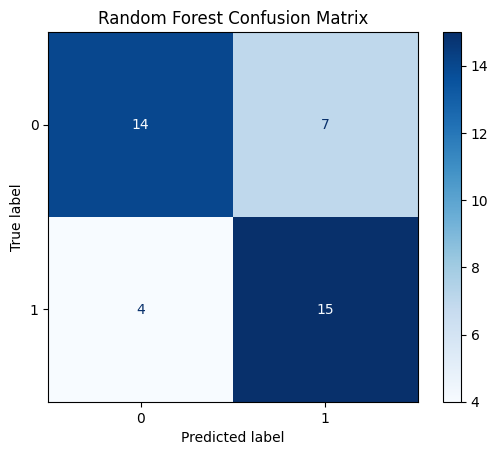

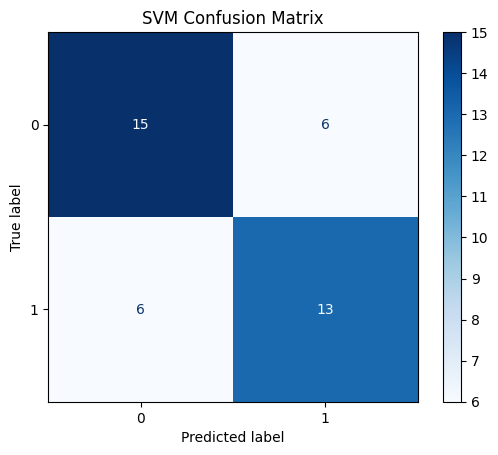

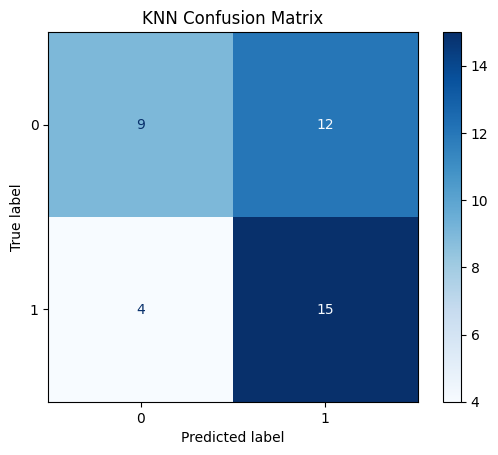

In [40]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")